<a href="https://colab.research.google.com/github/preethisedigar/data_analytics_projects/blob/main/LR%2BAdvertising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Performing Simple Linear Regression

Equation of linear regression<br>
$y = c + m_1x_1 + m_2x_2 + ... + m_nx_n$

-  $y$ is the response
-  $c$ is the intercept
-  $m_1$ is the coefficient for the first feature
-  $m_n$ is the coefficient for the nth feature

In our case:

y = c + m_1 * TV

The m values are called the model **coefficients** or **model parameters**.


In [ ]:
# importing necessary libraries
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# reading the data
data = pd.read_csv('advertising.csv')
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [ ]:
data.shape

(200, 4)

In [ ]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


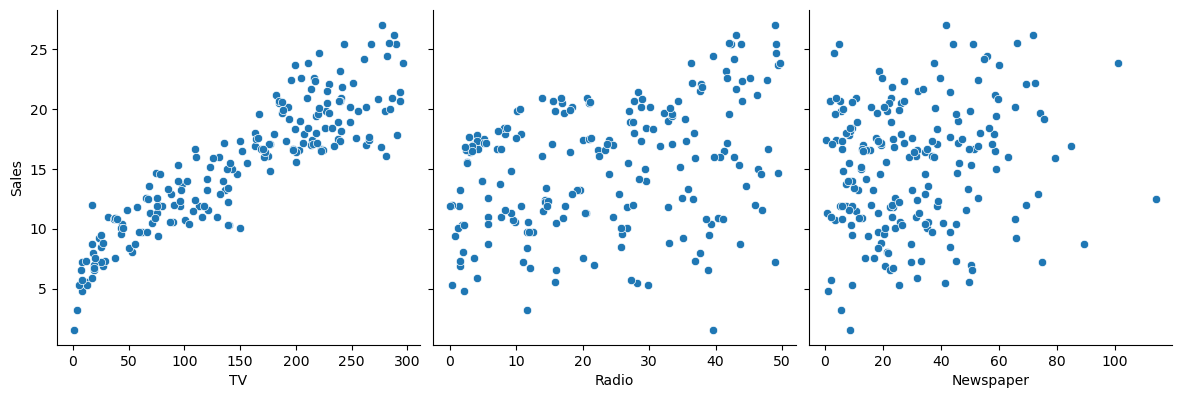

In [ ]:
sns.pairplot(data, x_vars = ['TV','Radio','Newspaper'], y_vars = ['Sales'], size = 4, kind = 'scatter')
plt.show()

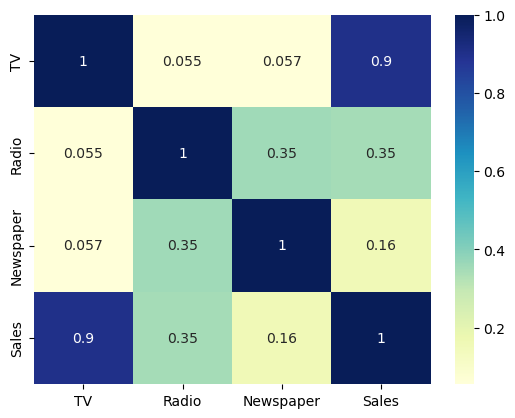

In [ ]:
sns.heatmap(data.corr(), annot = True, cmap = 'YlGnBu')
plt.show()

As is visible from the pairplot and the heatmap, the variable `TV` seems to be most correlated with `Sales`. So let's go ahead and perform simple linear regression using `TV` as our feature variable.

### Generic Steps in model building using `statsmodels`

We first assign the feature variable, `TV`, in this case, to the variable `X` and the response variable, `Sales`, to the variable `y`.

In [ ]:
# y = beta0 + beta1*TV

X = data['TV']
y = data['Sales']

In [ ]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

#### Building a Linear Model

You first need to import the `statsmodel.api` library using which you'll perform the linear regression.

By default, the `statsmodels` library fits a line on the dataset which passes through the origin. But in order to have an intercept, you need to manually use the `add_constant` attribute of `statsmodels`. And once you've added the constant to your `X_train` dataset, you can go ahead and fit a regression line using the `OLS` (Ordinary Least Squares) attribute of `statsmodels` as shown below

#### Train-Test Split

You now need to split our variable into training and testing sets. You'll perform this by importing `train_test_split` from the `sklearn.model_selection` library. It is usually a good practice to keep 70% of the data in your train dataset and the rest 30% in your test dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, train_size = 0.8, random_state = 42)

In [ ]:
X_train.head()

79     116.0
197    177.0
38      43.1
24      62.3
122    224.0
Name: TV, dtype: float64

In [ ]:
y_train.head()

79     11.0
197    14.8
38     10.1
24      9.7
122    16.6
Name: Sales, dtype: float64

In [ ]:
X_test.head()

95     163.3
15     195.4
30     292.9
158     11.7
128    220.3
Name: TV, dtype: float64

In [ ]:
y_test.head()

95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
Name: Sales, dtype: float64

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((160,), (40,), (160,), (40,))

In [ ]:
X_train_sm = sm.add_constant(X_train)
lr = sm.OLS(y_train, X_train_sm).fit()
lr.params

const    7.007108
TV       0.055483
dtype: float64

In [ ]:
# Performing a summary operation lists out all the different parameters of the regression line fitted
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     689.1
Date:                Wed, 04 Dec 2024   Prob (F-statistic):           1.71e-59
Time:                        04:01:46   Log-Likelihood:                -355.76
No. Observations:                 160   AIC:                             715.5
Df Residuals:                     158   BIC:                             721.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0071      0.364     19.274      0.0

####  Looking at some key statistics from the summary
The values we are concerned with are -
1. The coefficients and significance (p-values)
2. R-squared
3. F statistic and its significance

##### 1. The coefficient for TV is 0.054, with a very low p value
The coefficient is statistically significant. So the association is not purely by chance.

##### 2. R - squared is 0.816
Meaning that 81.6% of the variance in `Sales` is explained by `TV`

This is a decent R-squared value.

###### 3. F statistic has a very low p value (practically low)
Meaning that the model fit is statistically significant, and the explained variance isn't purely by chance.


---
The fit is significant. Let's visualize how well the model fit the data.

From the parameters that we get, our linear regression equation becomes:

Sales = 6.948 + 0.054 * TV

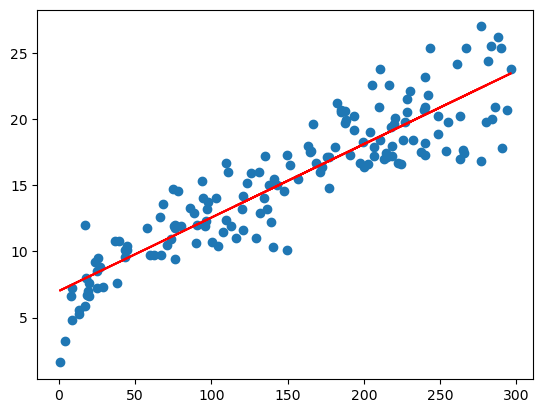

In [ ]:
# Sales = 7.0071 + 0.0555 * TV

plt.scatter(X_train, y_train)
plt.plot(X_train,7.0071 + 0.0555 * X_train, 'r')
plt.show()

## Residual analysis
To validate assumptions of the model, and hence the reliability for inference

#### Distribution of the error terms
We need to check if the error terms are also normally distributed (which is infact, one of the major assumptions of linear regression), let us plot the histogram of the error terms and see what it looks like.

In [ ]:
y_train_pred = lr.predict(X_train_sm)

In [ ]:
print(y_train_pred)

79     13.443130
197    16.827590
38      9.398423
24     10.463696
122    19.435288
         ...    
106     8.394182
14     18.331177
92     19.085745
179    16.195084
102    22.553429
Length: 160, dtype: float64


In [ ]:
res = (y_train - y_train_pred)
res

79    -2.443130
197   -2.027590
38     0.701577
24    -0.763696
122   -2.835288
         ...   
106   -1.194182
14     0.668823
92     0.314255
179    1.404916
102   -2.753429
Length: 160, dtype: float64

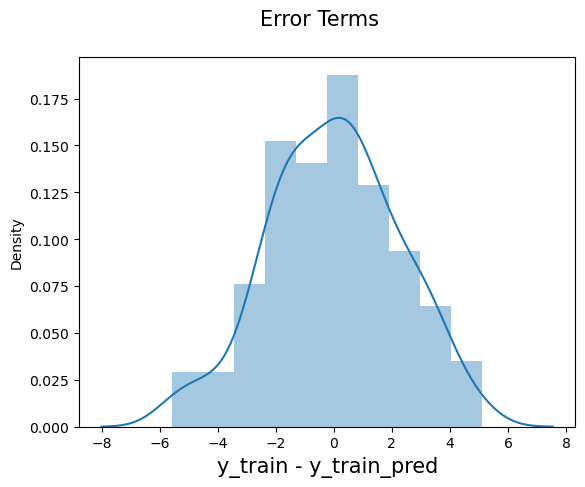

In [ ]:
fig = plt.figure()
sns.distplot(res, bins = 10)
fig.suptitle('Error Terms', fontsize = 15)
plt.xlabel('y_train - y_train_pred', fontsize= 15)
plt.show()

The residuals are following the normally distributed with a mean 0. All good!

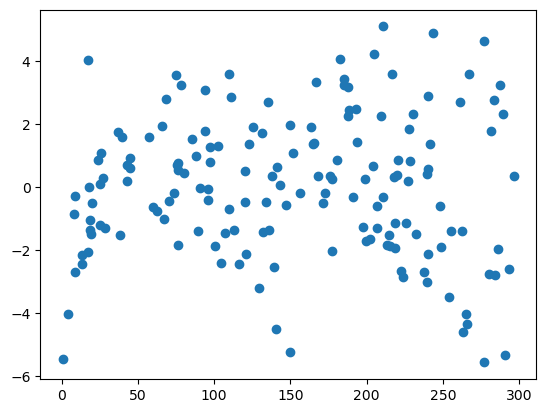

In [ ]:
plt.scatter(X_train, res)
plt.show()

We are confident that the model fit isn't by chance, and has decent predictive power. The normality of residual terms allows some inference on the coefficients.

Although, the variance of residuals increasing with X indicates that there is significant variation that this model is unable to explain.

## Predictions on the Test Set

Now that you have fitted a regression line on your train dataset, it's time to make some predictions on the test data. For this, you first need to add a constant to the `X_test` data like you did for `X_train` and then you can simply go on and predict the y values corresponding to `X_test` using the `predict` attribute of the fitted regression line.

In [ ]:
X_test_sm = sm.add_constant(X_test)
lr = sm.OLS(y_test, X_test_sm).fit()
lr.params

const    6.877789
TV       0.055146
dtype: float64

In [ ]:
y_test_pred = lr.predict(X_test_sm)
y_test_pred

95     15.883199
15     17.653399
30     23.030175
158     7.523002
128    19.026545
115    11.019285
69     18.833532
170     9.635110
174    19.142352
45     16.533927
66      8.614901
182     9.977018
165    19.809624
78      7.175579
186    14.570714
177    16.263709
56      7.280358
152    17.774721
82     11.030314
68     19.969548
124    19.533892
16     10.616716
148     8.973353
93     20.714025
65     10.682892
60      9.828122
84     18.651549
67     14.559685
125    11.686556
132     7.341019
9      17.896043
18     10.693921
55     17.846411
75      7.809763
150    22.357388
104    20.013666
135     9.541361
137    21.971363
164    13.340949
76      8.394315
dtype: float64

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
mean_squared_error(y_test, y_test_pred)

6.069594534314894

In [ ]:
r2_score(y_test, y_test_pred)

0.8035799847152725

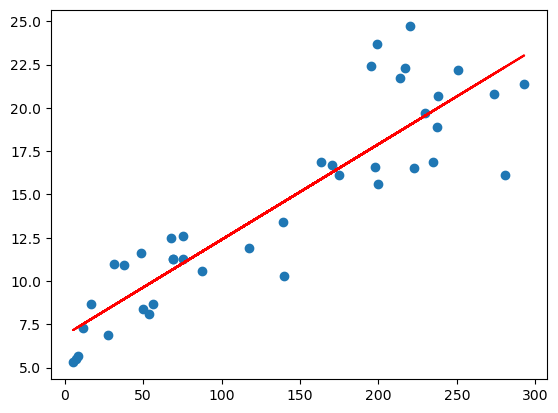

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X_test,6.877789 + 0.055146 * X_test, 'r')
plt.show()

In [ ]:
res = y_test - y_test_pred

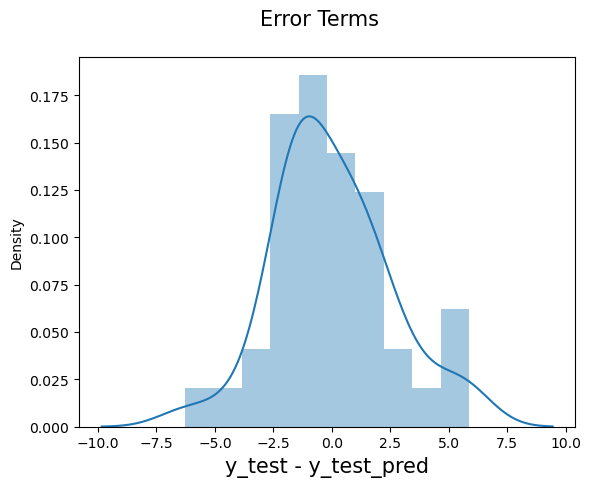

In [ ]:
fig = plt.figure()
sns.distplot(res, bins = 10)
fig.suptitle('Error Terms', fontsize = 15)
plt.xlabel('y_test - y_test_pred', fontsize= 15)
plt.show()

### Multiple Linear Regerssion
## Model 2 adding Radio and Newspaper

In [ ]:
X1 = data[['TV','Radio','Newspaper']]
y1 = data['Sales']

In [ ]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1,y1,test_size = 0.2, train_size = 0.8, random_state = 42)

In [ ]:
X1_train_sm = sm.add_constant(X1_train)
lr = sm.OLS(y1_train,X1_train_sm).fit()
lr.params

const        4.714126
TV           0.054509
Radio        0.100945
Newspaper    0.004337
dtype: float64

In [ ]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     468.7
Date:                Wed, 04 Dec 2024   Prob (F-statistic):           8.51e-78
Time:                        04:01:47   Log-Likelihood:                -305.78
No. Observations:                 160   AIC:                             619.6
Df Residuals:                     156   BIC:                             631.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7141      0.352     13.407      0.0

In [ ]:
y1_pred = lr.predict(X1_train_sm)

In [ ]:
y1_pred

79     11.914658
197    15.328814
38      9.910933
24      9.461326
122    17.234124
         ...    
106     7.316056
14     19.360057
92     20.218326
179    14.826640
102    21.099976
Length: 160, dtype: float64

In [ ]:
mean_squared_error(y1_train, y1_pred)

2.6761426537826685

In [ ]:
r2_score(y1_train, y1_pred)

0.9001416005862131

In [ ]:
X1_test_sm = sm.add_constant(X1_test)
lr = sm.OLS(y1_test, X1_test_sm).fit()
lr.params

const        4.073684
TV           0.053860
Radio        0.128354
Newspaper   -0.006290
dtype: float64

In [ ]:
y1_test_pred = lr.predict(X1_test_sm)
y1_test_pred

95     16.592282
15     20.387686
30     23.209996
158     9.155797
128    22.208270
115    12.279481
69     21.214198
170     8.139858
174    16.406176
45     16.194415
66      8.913941
182     7.645428
165    16.606898
78      8.143180
186    11.689400
177    14.020428
56      7.813201
152    17.617766
82     10.530509
68     20.320611
124    20.113693
16     11.706098
148    11.218174
93     21.817336
65      8.978060
60      7.077303
84     20.879428
67     13.373369
125    10.121951
132     8.004122
9      15.035307
18     10.316950
55     20.749739
75     10.030661
150    20.743606
104    21.272357
135    12.654288
137    22.149111
164    12.238923
76      5.630002
dtype: float64

In [ ]:
mean_squared_error(y1_test, y1_test_pred)

2.554720719896192

In [ ]:
r2_score(y1_test, y1_test_pred)

0.9173258971397072